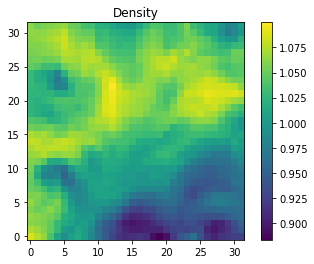

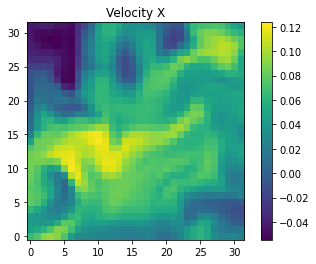

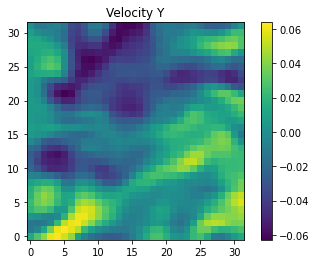

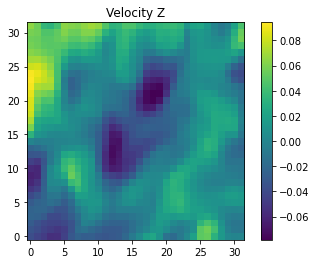

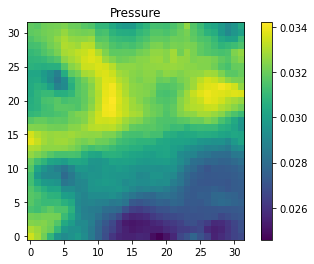

(64, 5, 32, 32, 32)


In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

filename = "/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.prim.00086.phdf"

with h5py.File(filename, 'r') as f:
    prim = f['prim'][:]  # fully load to memory

def show_midplane_slice(data, label):
    plt.imshow(data[0, :, :, 16], origin='lower')
    plt.title(label)
    plt.colorbar()
    plt.show()

show_midplane_slice(prim[:, 0], "Density")
show_midplane_slice(prim[:, 1], "Velocity X")
show_midplane_slice(prim[:, 2], "Velocity Y")
show_midplane_slice(prim[:, 3], "Velocity Z")
show_midplane_slice(prim[:, 4], "Pressure")

print(prim.shape)


In [3]:
print(prim[:, 0].shape)

(64, 32, 32, 32)


In [4]:
rho_flat = rho.flatten()
rho_filtered = rho_flat[rho_flat > 0]

# Define log-spaced bins
bins = np.logspace(np.log10(rho_filtered.min()), np.log10(rho_filtered.max()), 100)

plt.figure()
plt.hist(rho_filtered, bins=bins, log=True)
plt.xscale('log')
plt.xlabel("Density")
plt.ylabel("Cell Count")
plt.title("Density Distribution (log-log)")
plt.grid(True, which="both", ls='--')
plt.tight_layout()
plt.show()


NameError: name 'rho' is not defined

In [22]:
print(max(rho_flat))

1.0


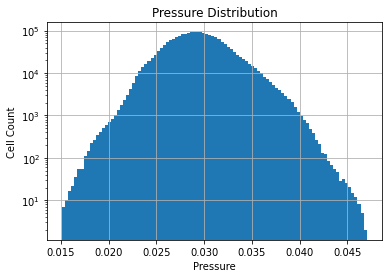

In [5]:
prs = prim[:, 4]
prs_flat = prs.flatten()

plt.hist(prs_flat, bins=100, log=True)
plt.xlabel("Pressure")
plt.ylabel("Cell Count")
plt.title("Pressure Distribution")
plt.grid(True)
plt.show()


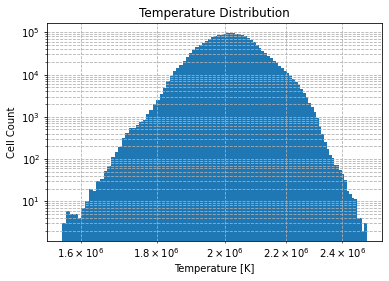

In [6]:
from units import KELVIN, mu

rho = prim[:, 0]
prs = prim[:, 4]

rho_safe = np.where(rho == 0, 1e-20, rho)
T = (prs / rho_safe) * (KELVIN * mu)
T_flat = T.flatten()

plt.figure()
plt.hist(T_flat, bins=100, log=True)
plt.xscale('log')
plt.xlabel("Temperature [K]")
plt.ylabel("Cell Count")
plt.title("Temperature Distribution")
plt.grid(True, which="both", ls='--')
plt.show()



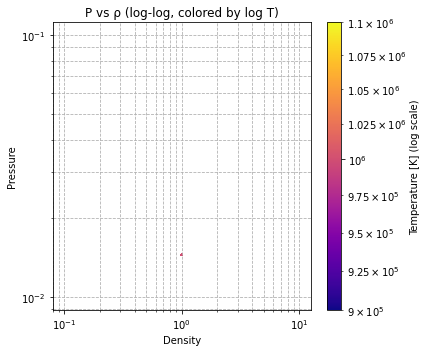

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(6, 5))

sc = plt.scatter(rho_flat, prs_flat, c=T_flat, s=1,
                 cmap='plasma', norm=LogNorm(vmin=T_flat.min(), vmax=T_flat.max()))

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Density")
plt.ylabel("Pressure")
plt.title("P vs ρ (log-log, colored by log T)")
cbar = plt.colorbar(sc)
cbar.set_label("Temperature [K] (log scale)")
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()



In [26]:
print(f"Minimum temperature: {T.max():.3e} K")


Minimum temperature: 1.000e+06 K
